## 1. Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

## 2. import and standard iris data
We use iris dataset, it's having four features and one traget column

As PCA affected by scale of the data. We can use scale function and standardise the actual values

In [2]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"
# load dataset into Pandas DataFrame
df = pd.read_csv(url, names=['sepal length','sepal width','petal length','petal width','target'])

In [3]:
df.head()

,sepal length,sepal width,petal length,petal width,target
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
feature = ['sepal length', 'sepal width', 'petal length', 'petal width']

# separating features
x = df.loc[:,feature]

# separating target
y = df.loc[:,'target']

#Standardising features
x = StandardScaler().fit_transform(x)

## 3. PCA execution and Projection to 2D

In [5]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pct = pca.fit_transform(x)

principal_df = pd.DataFrame(pct,columns=['pc1','pc2'])

finaldf= pd.concat([principal_df,df[['target']]],axis=1)

In [6]:
finaldf.head()

,pc1,pc2,target
0,-2.264542,0.505704,Iris-setosa
1,-2.086426,-0.655405,Iris-setosa
2,-2.367950,-0.318477,Iris-setosa
3,-2.304197,-0.575368,Iris-setosa
4,-2.388777,0.674767,Iris-setosa


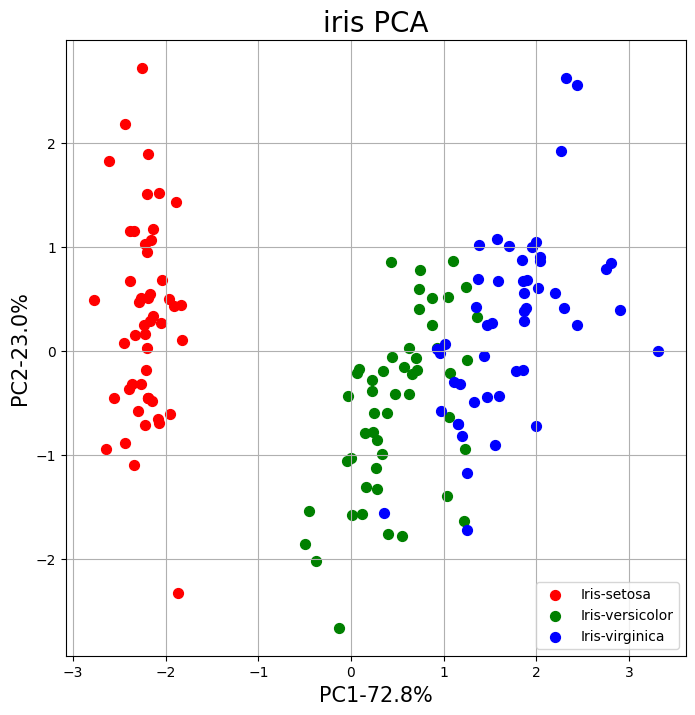

In [7]:
fig = plt.figure(figsize = (8,8))
ax = fig.add_subplot(1,1,1) 
pcv = pca.explained_variance_ratio_

ax.set_xlabel(f'PC1-{pcv[0]*100:.1f}%', fontsize = 15)
ax.set_ylabel(f'PC2-{pcv[1]*100:.1f}%', fontsize = 15)
ax.set_title('iris PCA', fontsize = 20)
targets = ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
colors = ['r', 'g', 'b']
for target, color in zip(targets,colors):
    indicesToKeep = finaldf['target'] == target
    ax.scatter(finaldf.loc[indicesToKeep, 'pc1']
               , finaldf.loc[indicesToKeep, 'pc2']
               , c = color
               , s = 50)
ax.legend(targets)
ax.grid()

解释的方差告诉我们有多少信息（方差）可以归因于每个主要成分。因为虽然可以将4维空间转换为2维空间，但这样做会丢失一些方差（信息）。通过使用属性explained_variance_ratio_，您可以看到第一主成分包含72.77%的方差，第二主成分包含23.03%的方差。这两个部分共同包含95.80%的信息。

In [8]:
pca.explained_variance_ratio_

array([0.72770452, 0.23030523])

模型准确率: 0.978


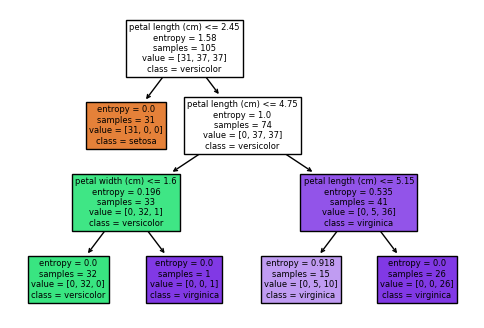

In [9]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
import matplotlib.pyplot as plt
 
iris = load_iris()  # 加载示例数据集
X = iris.data       # 特征
y = iris.target     # 标签
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
 
# 创建决策树分类器
clf = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)
clf.fit(X_train, y_train)       # 训练模型
y_pred = clf.predict(X_test)    # 预测
accuracy = clf.score(X_test, y_test)    # 模型准确率
print(f"模型准确率: {accuracy:.3f}")
 
plt.figure(figsize=(6, 4))     # 可视化决策树
tree.plot_tree(clf, feature_names=iris.feature_names, class_names=iris.target_names, filled=True)
plt.show()